In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

In [6]:
iris = pd.DataFrame(load_iris().data, columns = load_iris().feature_names)

In [7]:
iris

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [8]:
from sklearn.preprocessing import StandardScaler

In [9]:
scaler = StandardScaler()

In [10]:
x_scaled = scaler.fit_transform(iris)

In [12]:
x_scaled.shape

(150, 4)

In [14]:
from sklearn.decomposition import PCA

In [15]:
pca = PCA(n_components=2)

In [17]:
x_pca = pca.fit_transform(x_scaled)

In [18]:
x_pca.shape

(150, 2)

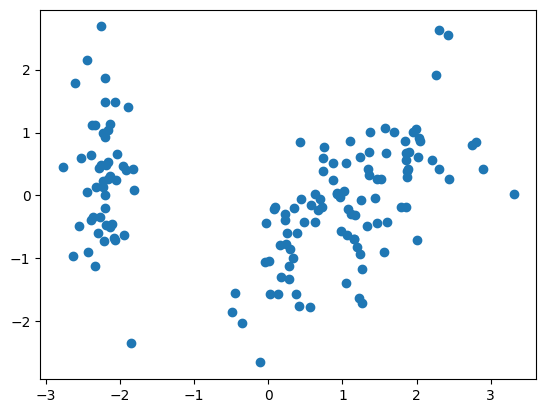

In [19]:
plt.scatter(x_pca[:,0],x_pca[:,1])

In [20]:
## Agglomerative Cluster
## To construct a dendogram
import scipy.cluster.hierarchy as sc

Text(0, 0.5, 'Eucledian Distance')

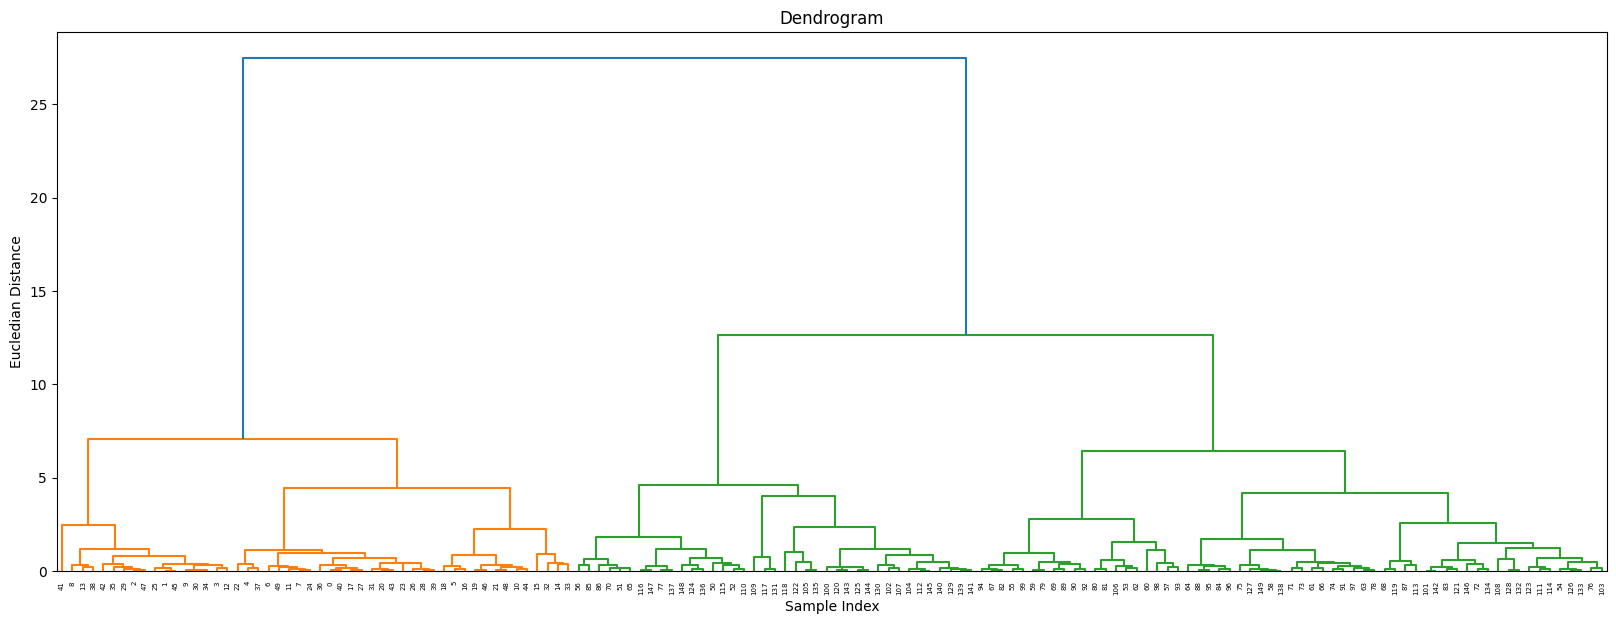

In [22]:
## create a dendogram
plt.figure(figsize=(20,7))
sc.dendrogram(sc.linkage(x_pca,method='ward'))
plt.title('Dendrogram')
plt.xlabel('Sample Index')
plt.ylabel('Eucledian Distance')

In [24]:
from sklearn.cluster import AgglomerativeClustering
agg_cluster = AgglomerativeClustering(n_clusters=2,metric='euclidean', linkage='ward')

In [25]:
agg_cluster.fit(x_pca)


AgglomerativeClustering()

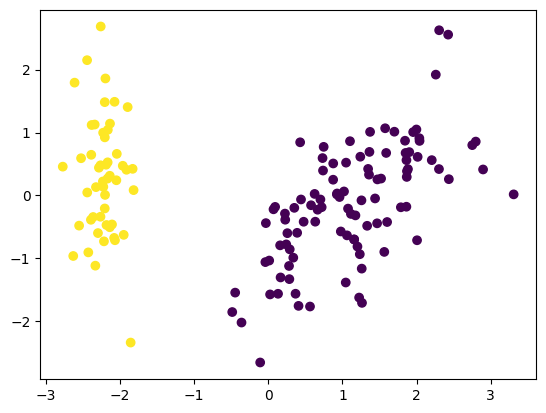

In [27]:
plt.scatter(x_pca[:,0],x_pca[:,1], c=agg_cluster.labels_)

In [29]:
from sklearn.metrics import silhouette_score

In [30]:
silhoette = []
for k in range(2,21):
    agg_cluster = AgglomerativeClustering(n_clusters=k,metric='euclidean', linkage='ward')
    agg_cluster.fit(x_pca)
    silhoette.append(silhouette_score(x_pca,agg_cluster.labels_))

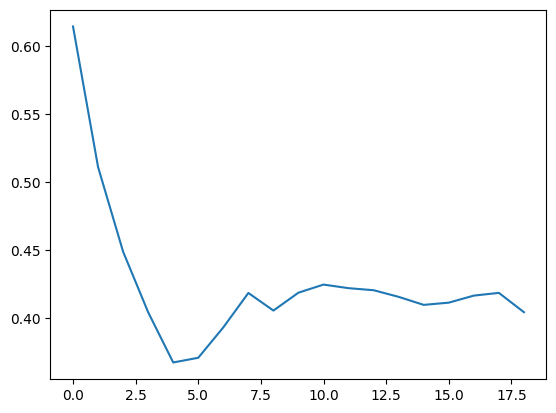

In [33]:
plt.plot(silhoette)